In [1]:
# core point : 반지름 안에 있는 점들
# core point >= min_samples(최소 기준)
# core -> core-> core : 자연스럽게 군집을 형성
# 밀도가 높은곳은 계속 연결됨 -> 하나의 큰 덩어리인 클러스터

# 반지름 안에 있는 점들을 찾는 문제 -> 주어진 중심점과 반지름을 기준으로 해당 반지름 안에 위치한 점들을 찾는 문제
# 주로 2차원 평면에서 다루어짐
# 중심점 / 반지름 주어졌을 때 -> 해당 반지름 안에 있는 점들의 좌표 반환


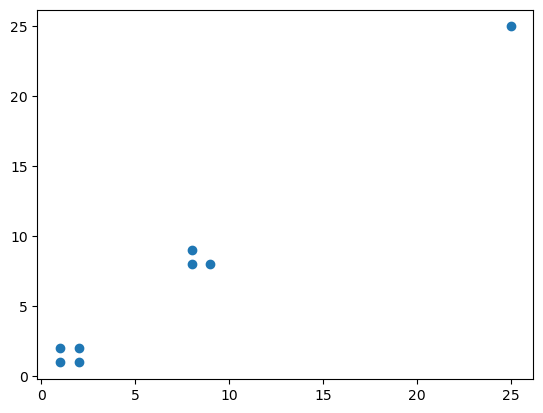

In [1]:
# 샘플 데이터 
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [1,1], [1,2], [2,1], [2,2], [8,8], [8,9], [9,8], [25,25]
])

plt.scatter(X[:,0], X[:,1])
plt.show()

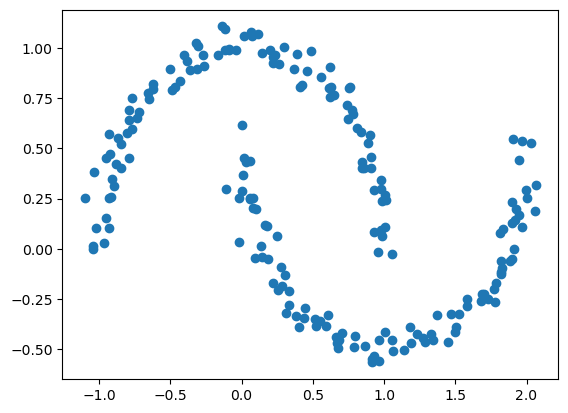

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

np.random.seed(42)

X, y = make_moons(
    n_samples=200, noise=0.05, random_state=42
)

plt.scatter(X[:,0], X[:,1])
plt.show()

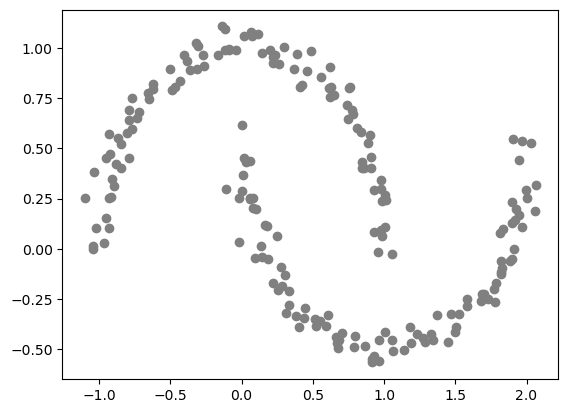

In [43]:
# 1. 초기화 (모든 점 미방문)

un_visited = -1
noise = -2
n = len(X)
labels = np.full(n, un_visited)

eps = 0.3
min_samples = 5
cluster_id = 0

plt.scatter(X[:,0], X[:,1], c='gray')
plt.show()

In [52]:
# 2. 반경 내 이웃 찾기

def region_query(X, point_idx, eps):
    '''
    X : 전체 데이터 셋
    point_idx : 기준점 Core point 후보 인덱스
    eps : 이웃으로 인정하기 위한 최대거리 (반경)
    return : neighbors
    '''
    distance = np.linalg.norm(
        X - X[point_idx],
        axis=1  # 열 단위로 연산
    )
    neighbors = np.where(distance <= eps)[0]
    return neighbors

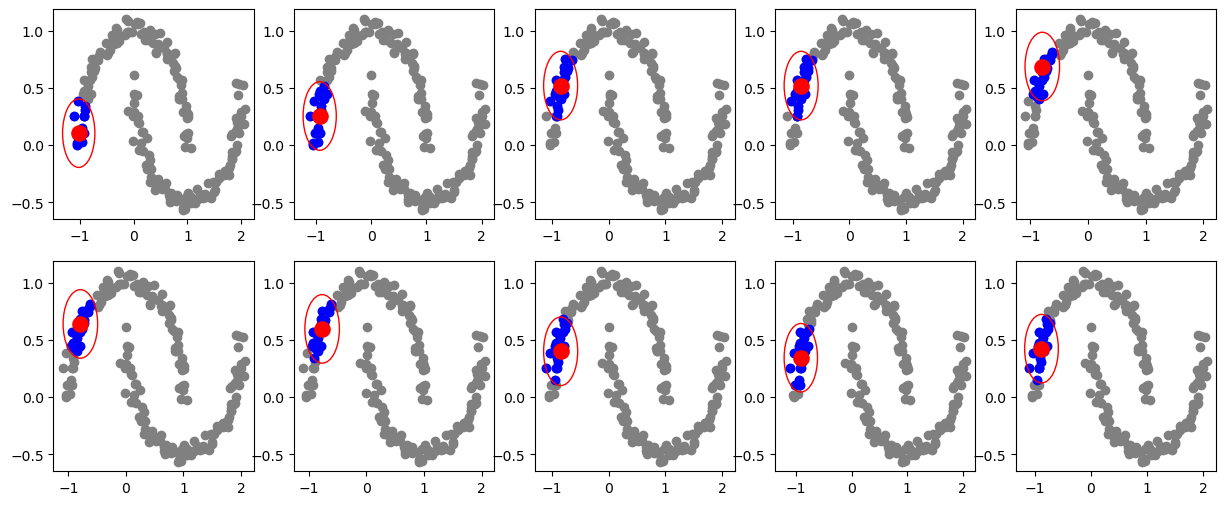

In [53]:
# 3. core point 확인
neighbors = region_query(X, 0, eps)

fig, ax = plt.subplots(2,5, figsize=(15,6))

for i in range(10):
    point_index = neighbors[i]
    neighbors = region_query(X, point_index, eps)
    # 전체 점
    ax[i//5, i%5].scatter(X[:,0], X[:,1], c='gray')

    # 이웃 점
    ax[i//5, i%5].scatter(
        X[neighbors,0], X[neighbors,1],
        c='blue'
    )
    # 현재 점
    ax[i//5, i%5].scatter(
        X[point_index,0], X[point_index,1],
        c='red', s=120
    )
    
    # eps 원
    circle = plt.Circle(
        X[point_index], eps, color='red', fill=False
    )
    ax[i//5, i%5].add_patch(circle)
plt.show()

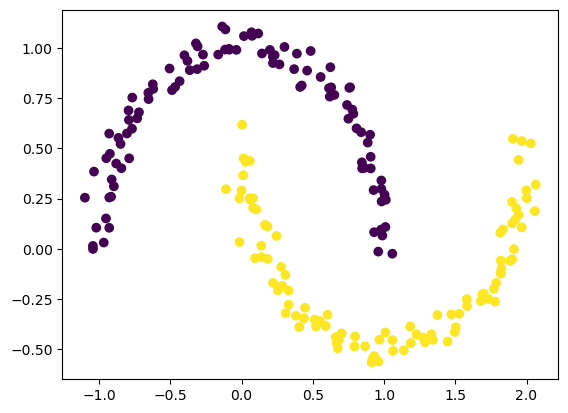

In [21]:
# 라이브러리 이용
from sklearn.cluster import DBSCAN
model = DBSCAN(eps=0.3, min_samples=5)
sk_labels = model.fit_predict(X)

plt.scatter(
    X[:,0], X[:,1], c=sk_labels
)
plt.show()

In [55]:
# 계층적 군집화
# 처음에는 모든 점이 혼자 있음
# 가장 가까운 두 점 찾기
# 그 둘을 하나의 그룹으로 묶기
# 다시 가장 가까운 그룹 찾기
# 반복
# 결국 하나의 그룹이 됨

# 섬들이 점점 다리로 연결되는 과정 

# 덴드로그램 (dendrogram)

왼쪽 그룹 오른쪽 그룹

P0 ● ● P1

             P2 ●
                    ● P3

        가운데 멀리

                  ● P4
                  ● P5

In [ ]:
# 군집간 거리
# Linkage Cirterion
# single Kinkage (가장 가까운 점 기준)
# complete Linkage (가장 먼 점 기준)
# Average Linkage (모든 점 거리 기준)

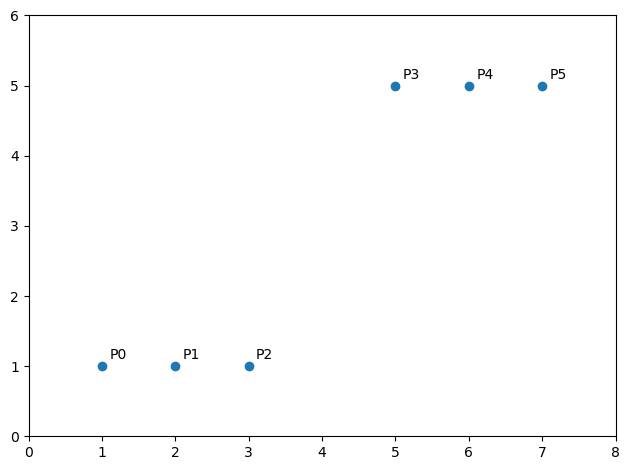

In [64]:
import numpy as np
import matplotlib.pyplot as plt

# 사슬모양
x = np.array([
    [1,1], [2,1], [3,1], [5,5], [6,5], [7,5]
])
plt.scatter(x[:,0], x[:,1])
for i, (X,y) in enumerate(x):
    plt.text(X+0.1, y+0.1, f'P{i}')

plt.ylim(0,6)
plt.xlim(0,8)

plt.tight_layout()
plt.show()

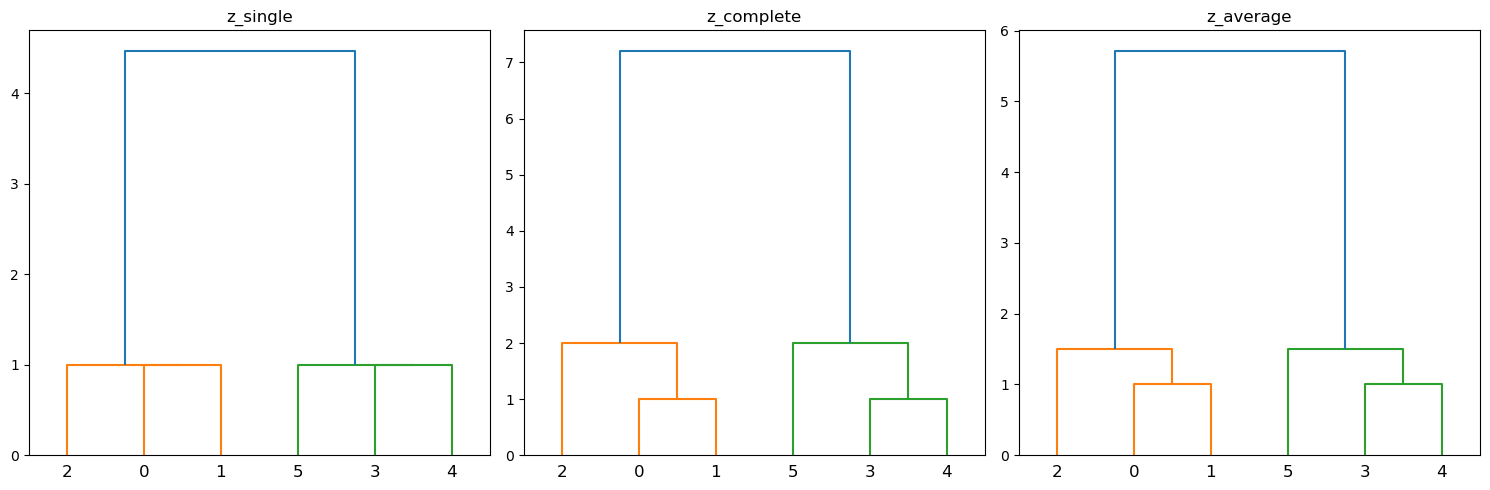

In [65]:
from scipy.cluster.hierarchy import linkage
z_single = linkage(x, method='single')
z_complete = linkage(x, method='complete')
z_average = linkage(x, method='average')

from scipy.cluster.hierarchy import dendrogram

fig, ax = plt.subplots(1,3, figsize=(15,5))
dendrogram(z_single, ax=ax[0])
dendrogram(z_complete, ax=ax[1])
dendrogram(z_average, ax=ax[2])

ax[0].set_title('z_single');ax[1].set_title('z_complete');ax[2].set_title('z_average')

plt.tight_layout()
plt.show()

In [62]:
# single Kinkage : 연결만 되면 같은 군집 / 군집이 계속 이어지는 모양
# complete Linkage : 군집이 더 단단해짐 / 퍼지는 것을 막음 / 더 조밀함
# Average Linkage : 균형잡힌 결과

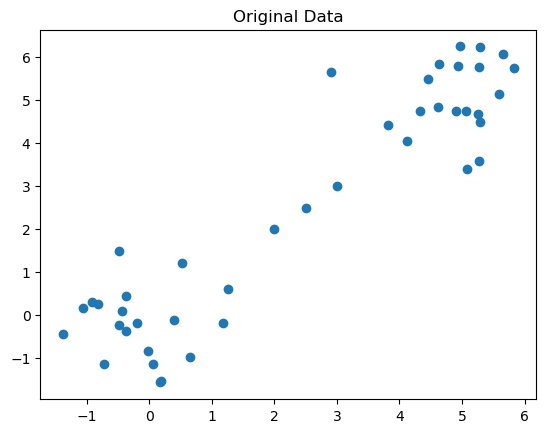

In [78]:
# 데이터 생성
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs

# 재현성
np.random.seed(42)

# 두 개 군집 생성
X, _ = make_blobs(
    n_samples=40,
    centers=[[0,0], [5,5]],
    cluster_std=0.8
)

# 가운데 연결점 추가 (중요!)
bridge = np.array([
    [2,2],
    [2.5,2.5],
    [3,3]
])

X = np.vstack([X, bridge])

# 데이터 시각화
plt.figure()

plt.scatter(X[:,0], X[:,1])

plt.title("Original Data")

plt.show()

# 점 3개가 두 군집을 형성하는 핵심

In [81]:
from sklearn.cluster import AgglomerativeClustering
n_clusters = 3

# singel
model_single = AgglomerativeClustering(n_clusters=n_clusters, linkage='single')
model_complete = AgglomerativeClustering(n_clusters=n_clusters, linkage='complete')
model_average = AgglomerativeClustering(n_clusters=n_clusters, linkage='average')

label_single = model_single.fit_predict(X)
label_complete = model_complete.fit_predict(X)
label_average = model_average.fit_predict(X)

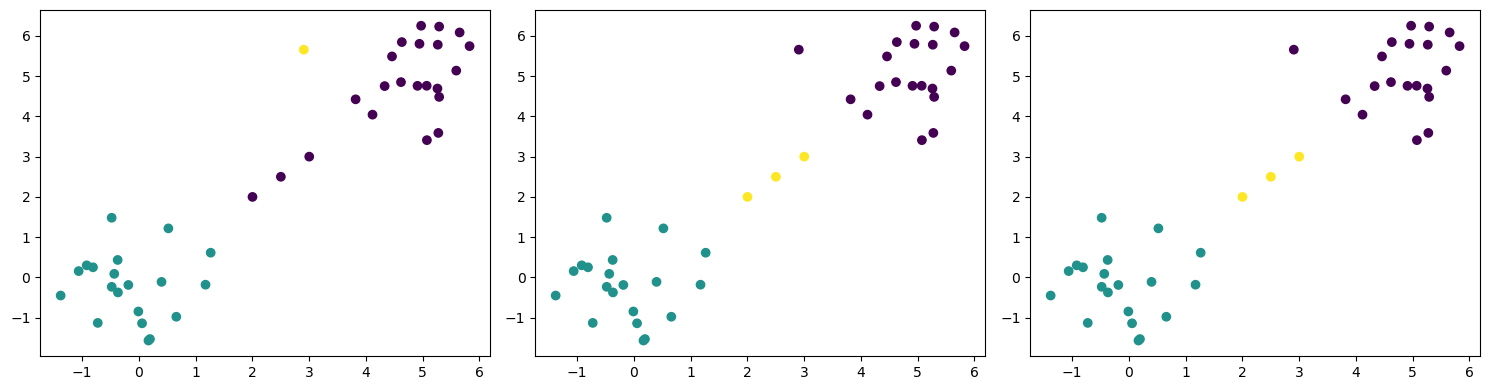

In [82]:
fig, ax = plt.subplots(1,3,figsize=(15,4))
ax[0].scatter(X[:,0], X[:,1], c=label_single)
ax[1].scatter(X[:,0], X[:,1], c=label_complete)
ax[2].scatter(X[:,0], X[:,1], c=label_average)

plt.tight_layout()
plt.show()